In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [36]:
!pip install wandb lightgbm catboost -q

# Imports, Constants and Paths

In [9]:
import os
import glob
from pathlib import Path
from IPython.display import FileLink
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import random
import torch
import torch.nn as nn
import wandb
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import pickle
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

DATA_SEED    = 67
SR           = 22050
DURATION     = 5.0
N_FFT        = 2048
HOP_LENGTH   = 512
N_MELS       = 128
TOP_DB       = 20
TARGET_SNR_DB = 10

random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)

wandb.login()

DATA_ROOT = Path('/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup')
GENRES    = ["blues", "classical", "country", "disco", "hiphop",
             "jazz", "metal", "pop", "reggae", "rock"]
STEMS     = {"drums": "drums.wav", "vocals": "vocals.wav",
             "bass": "bass.wav",   "other":  "other.wav"}
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
MASHUPS_PATH = DATA_ROOT / "mashups"
TEST_CSV     = DATA_ROOT / "test.csv"
STEMS_PATH = DATA_ROOT / "genres_stems"
ESC50_PATH   = DATA_ROOT / "ESC-50-master" / "audio"

Device: cuda


# **Milestone 1 : Data Exploration & Baseline Submission**

# *EDA on the dataset (class distribution, audio length, gaps, ESC-50 noise)*

In [3]:
def build_dataset(root_dir, val_split=0.17, seed=42):
    train_dataset = {g: {s.replace('.wav',''): [] for s in STEMS} for g in GENRES}
    val_dataset   = {g: {s.replace('.wav',''): [] for s in STEMS} for g in GENRES}
    rng = random.Random(seed)

    for genre in GENRES:
        genre_path = os.path.join(root_dir, "genres_stems", genre)
        if not os.path.isdir(genre_path): continue

        valid_songs = []
        for song in os.listdir(genre_path):
            song_path = os.path.join(genre_path, song)
            if not os.path.isdir(song_path): continue
            complete = all(
                os.path.exists(os.path.join(song_path, sf))
                for sf in STEMS.values()
            )
            if complete:
                valid_songs.append(song_path)

        rng.shuffle(valid_songs)
        split_idx   = int(len(valid_songs) * (1 - val_split))
        train_songs = valid_songs[:split_idx]
        val_songs   = valid_songs[split_idx:]

        for song_path in train_songs:
            for key, sf in STEMS.items():
                train_dataset[genre][key].append(os.path.join(song_path, sf))
        for song_path in val_songs:
            for key, sf in STEMS.items():
                val_dataset[genre][key].append(os.path.join(song_path, sf))

    return train_dataset, val_dataset

tr, val = build_dataset(DATA_ROOT)
print("Train songs per genre:", {g: len(tr[g]['drums']) for g in GENRES})
print("Val songs per genre:",   {g: len(val[g]['drums']) for g in GENRES})

Train songs per genre: {'blues': 83, 'classical': 83, 'country': 83, 'disco': 83, 'hiphop': 83, 'jazz': 83, 'metal': 83, 'pop': 83, 'reggae': 83, 'rock': 83}
Val songs per genre: {'blues': 17, 'classical': 17, 'country': 17, 'disco': 17, 'hiphop': 17, 'jazz': 17, 'metal': 17, 'pop': 17, 'reggae': 17, 'rock': 17}


*Equal songs per genre in both train and val sets*

Analyzing audio lengths


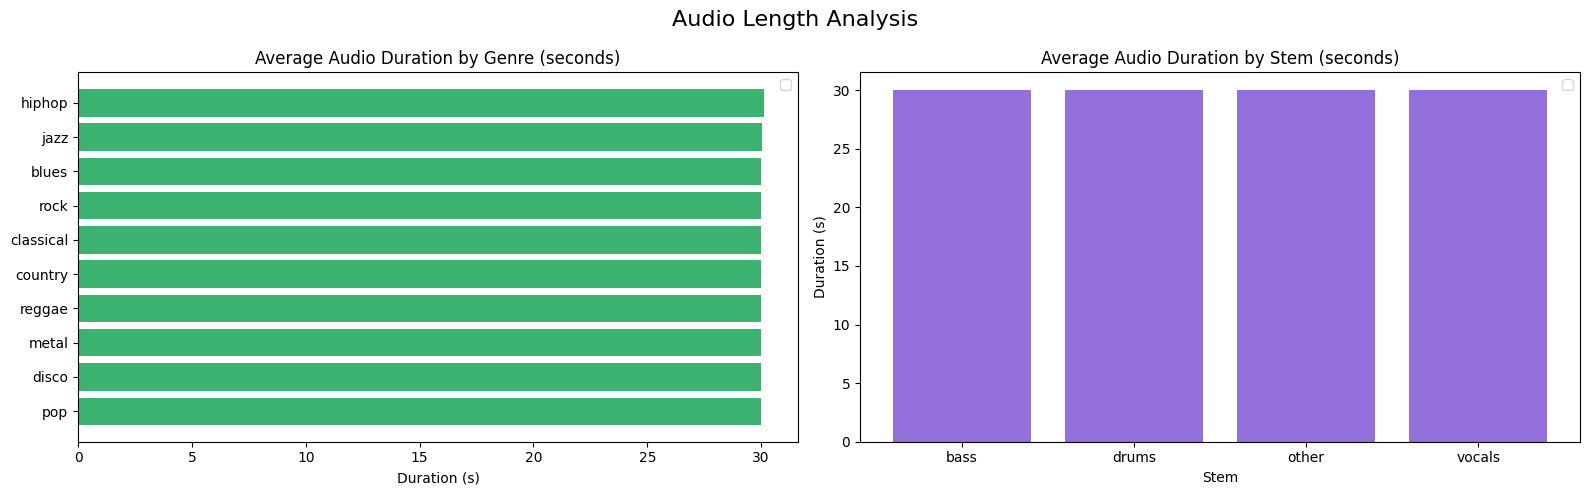


Overall stats:
count    400.00
mean      30.02
std        0.07
min       30.00
25%       30.00
50%       30.01
75%       30.01
max       30.65
Name: duration, dtype: float64


In [4]:
# Audio  Length Analysis

print("Analyzing audio lengths")
length_records = []

for genre in GENRES:
    for key in STEM_KEYS:
        for fp in tr[genre][key][:10]:  
            try:
                duration = librosa.get_duration(path=fp)
                length_records.append({
                    'genre': genre,
                    'stem':  key,
                    'duration': duration
                })
            except:
                pass

df_lengths = pd.DataFrame(length_records)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Duration by genre
genre_dur = df_lengths.groupby('genre')['duration'].mean().sort_values()
axes[0].barh(genre_dur.index, genre_dur.values, color='mediumseagreen')
axes[0].set_title('Average Audio Duration by Genre (seconds)')
axes[0].set_xlabel('Duration (s)')
axes[0].legend()

# Duration by stem
stem_dur = df_lengths.groupby('stem')['duration'].mean()
axes[1].bar(stem_dur.index, stem_dur.values, color='mediumpurple')
axes[1].set_title('Average Audio Duration by Stem (seconds)')
axes[1].set_xlabel('Stem')
axes[1].set_ylabel('Duration (s)')
axes[1].legend()

plt.suptitle('Audio Length Analysis', fontsize=16)
plt.tight_layout()
plt.savefig('audio_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOverall stats:")
print(df_lengths['duration'].describe().round(2))


- *Every genre has an average of 30 seconds per stem*
- *All 4 stems (bass, drums, other, vocals) have an average of 30 seconds*
- *For our model, we can use 10-15 seconds per audio to capture various patterns for different genres and no genre has an unfair advantage of duration*


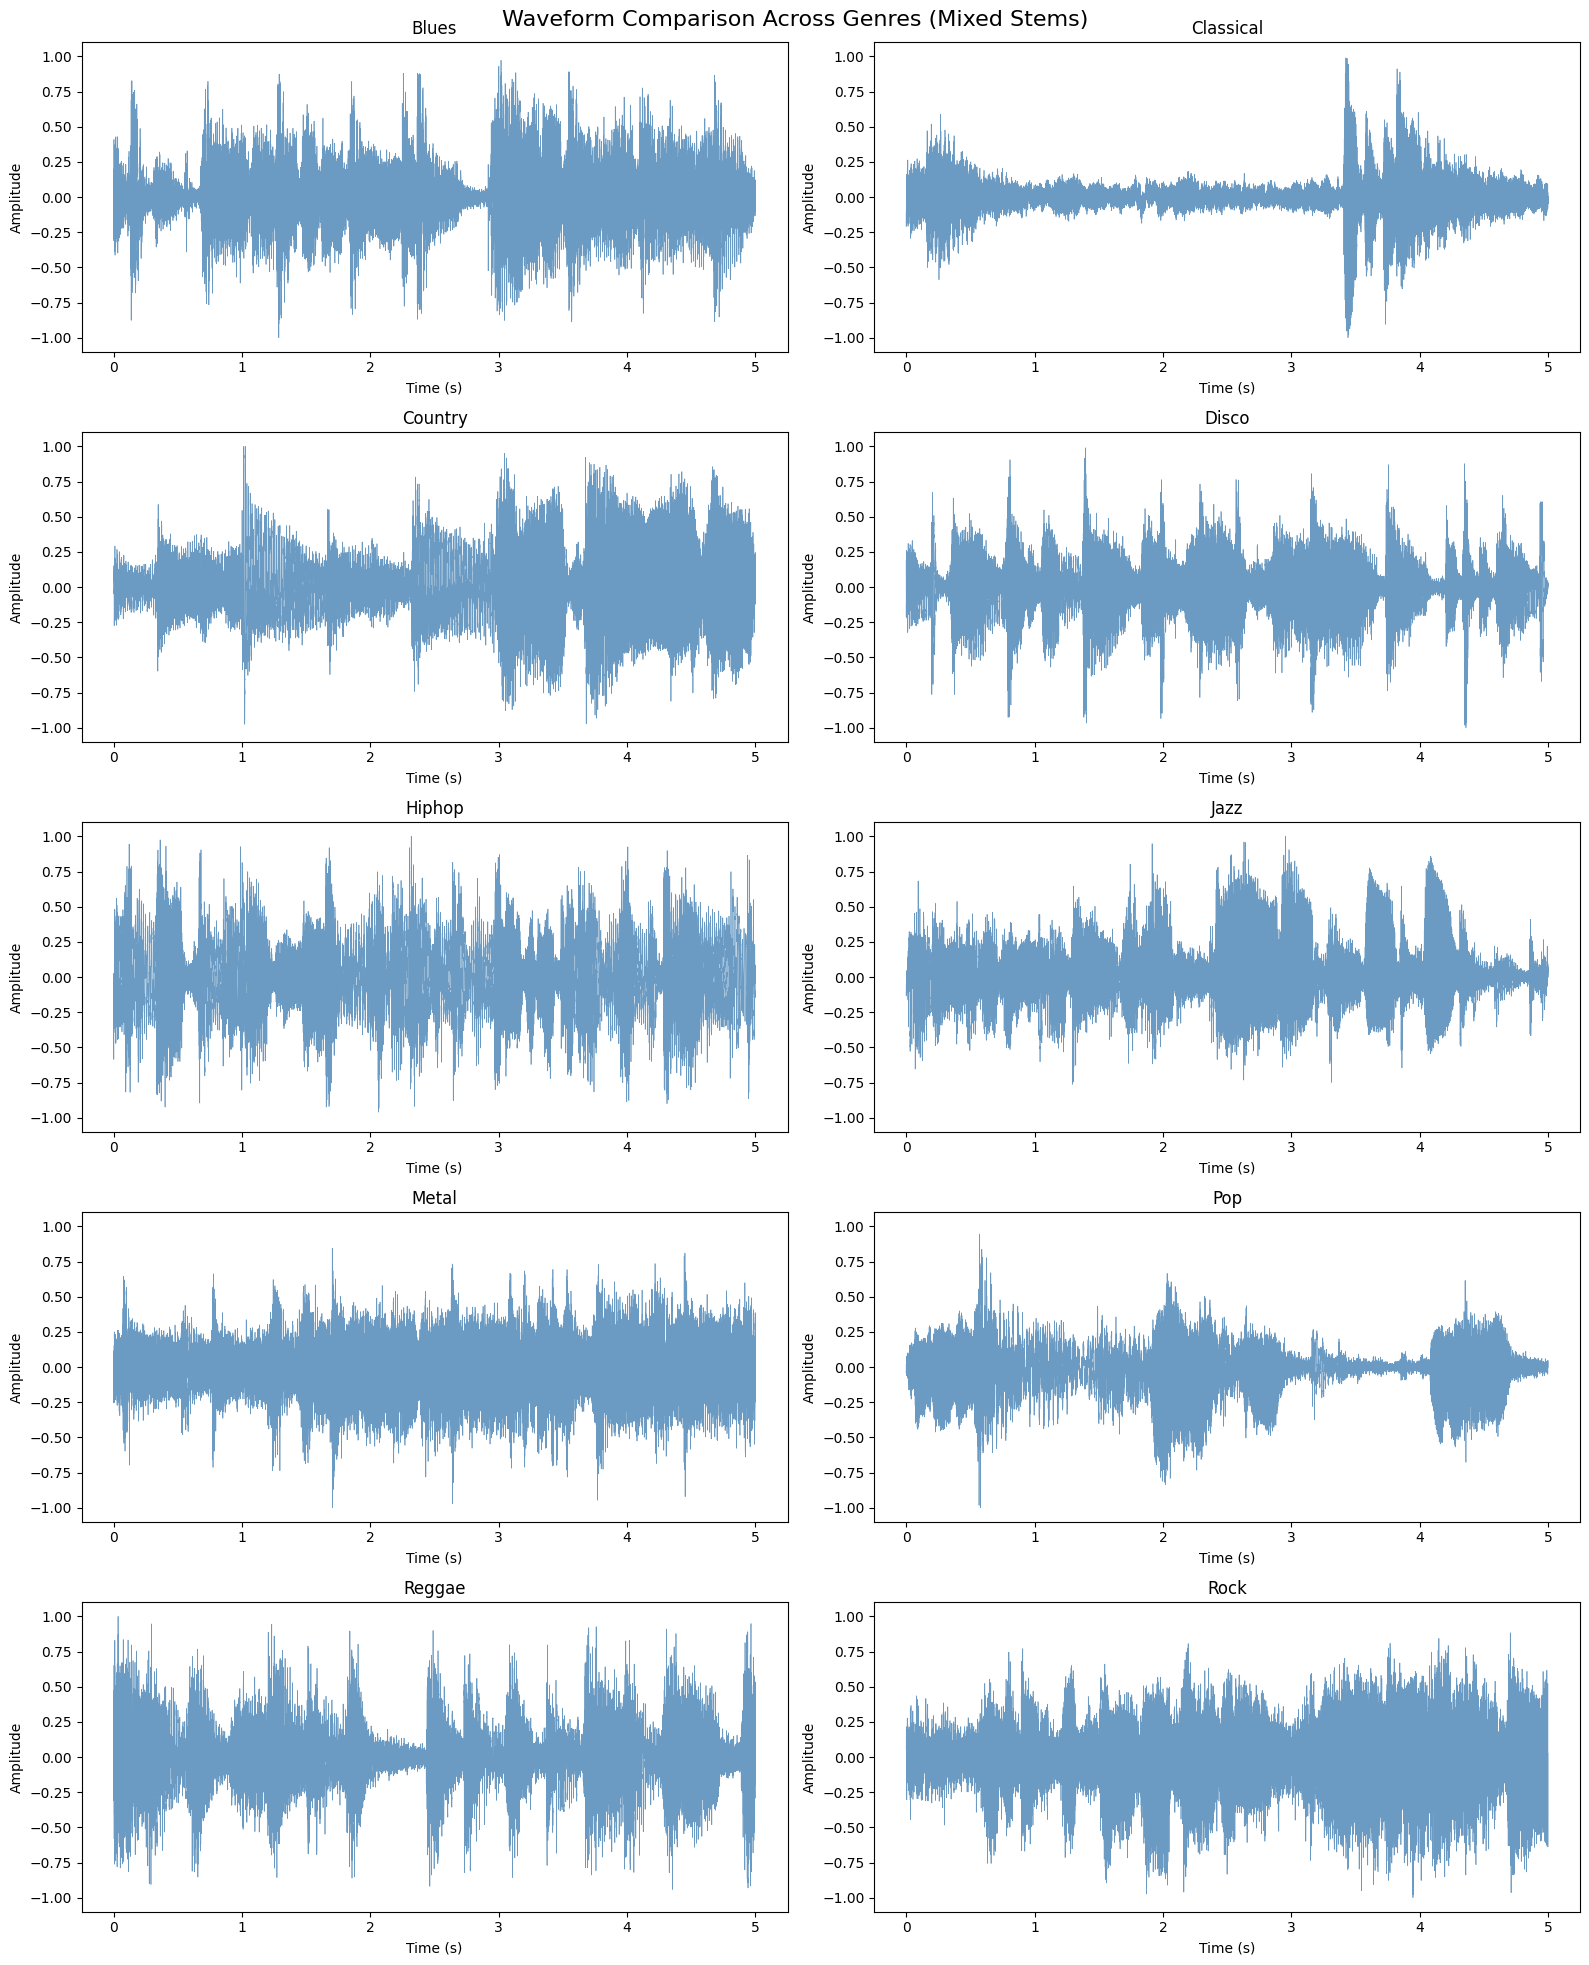

In [24]:
# Waveform distribution per Genre

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, genre in enumerate(GENRES):
    # Load and mix all 4 stems
    mixed = np.zeros(int(SR * DURATION))
    for key in STEM_KEYS:
        fp = tr[genre][key][0]
        y, _ = librosa.load(fp, sr=SR, duration=DURATION)
        y = librosa.util.fix_length(y, size=int(SR * DURATION))
        mixed += y

    # Normalize
    if np.max(np.abs(mixed)) > 0:
        mixed = mixed / np.max(np.abs(mixed))

    times = np.linspace(0, DURATION, len(mixed))
    axes[i].plot(times, mixed, color='steelblue', linewidth=0.5, alpha=0.8)
    axes[i].set_title(f'{genre.capitalize()}', fontsize=12)
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Amplitude')
    axes[i].set_ylim(-1.1, 1.1)

plt.suptitle('Waveform Comparison Across Genres (Mixed Stems)', fontsize=16)
plt.tight_layout()
plt.savefig('waveforms.png', dpi=150, bbox_inches='tight')
plt.show()

- *Waveforms depicts amplitude vs time for a sound audio*
- *They depict how loud the sound was at different instances of time*
- *They do not tell us what frequency the sound was played in*

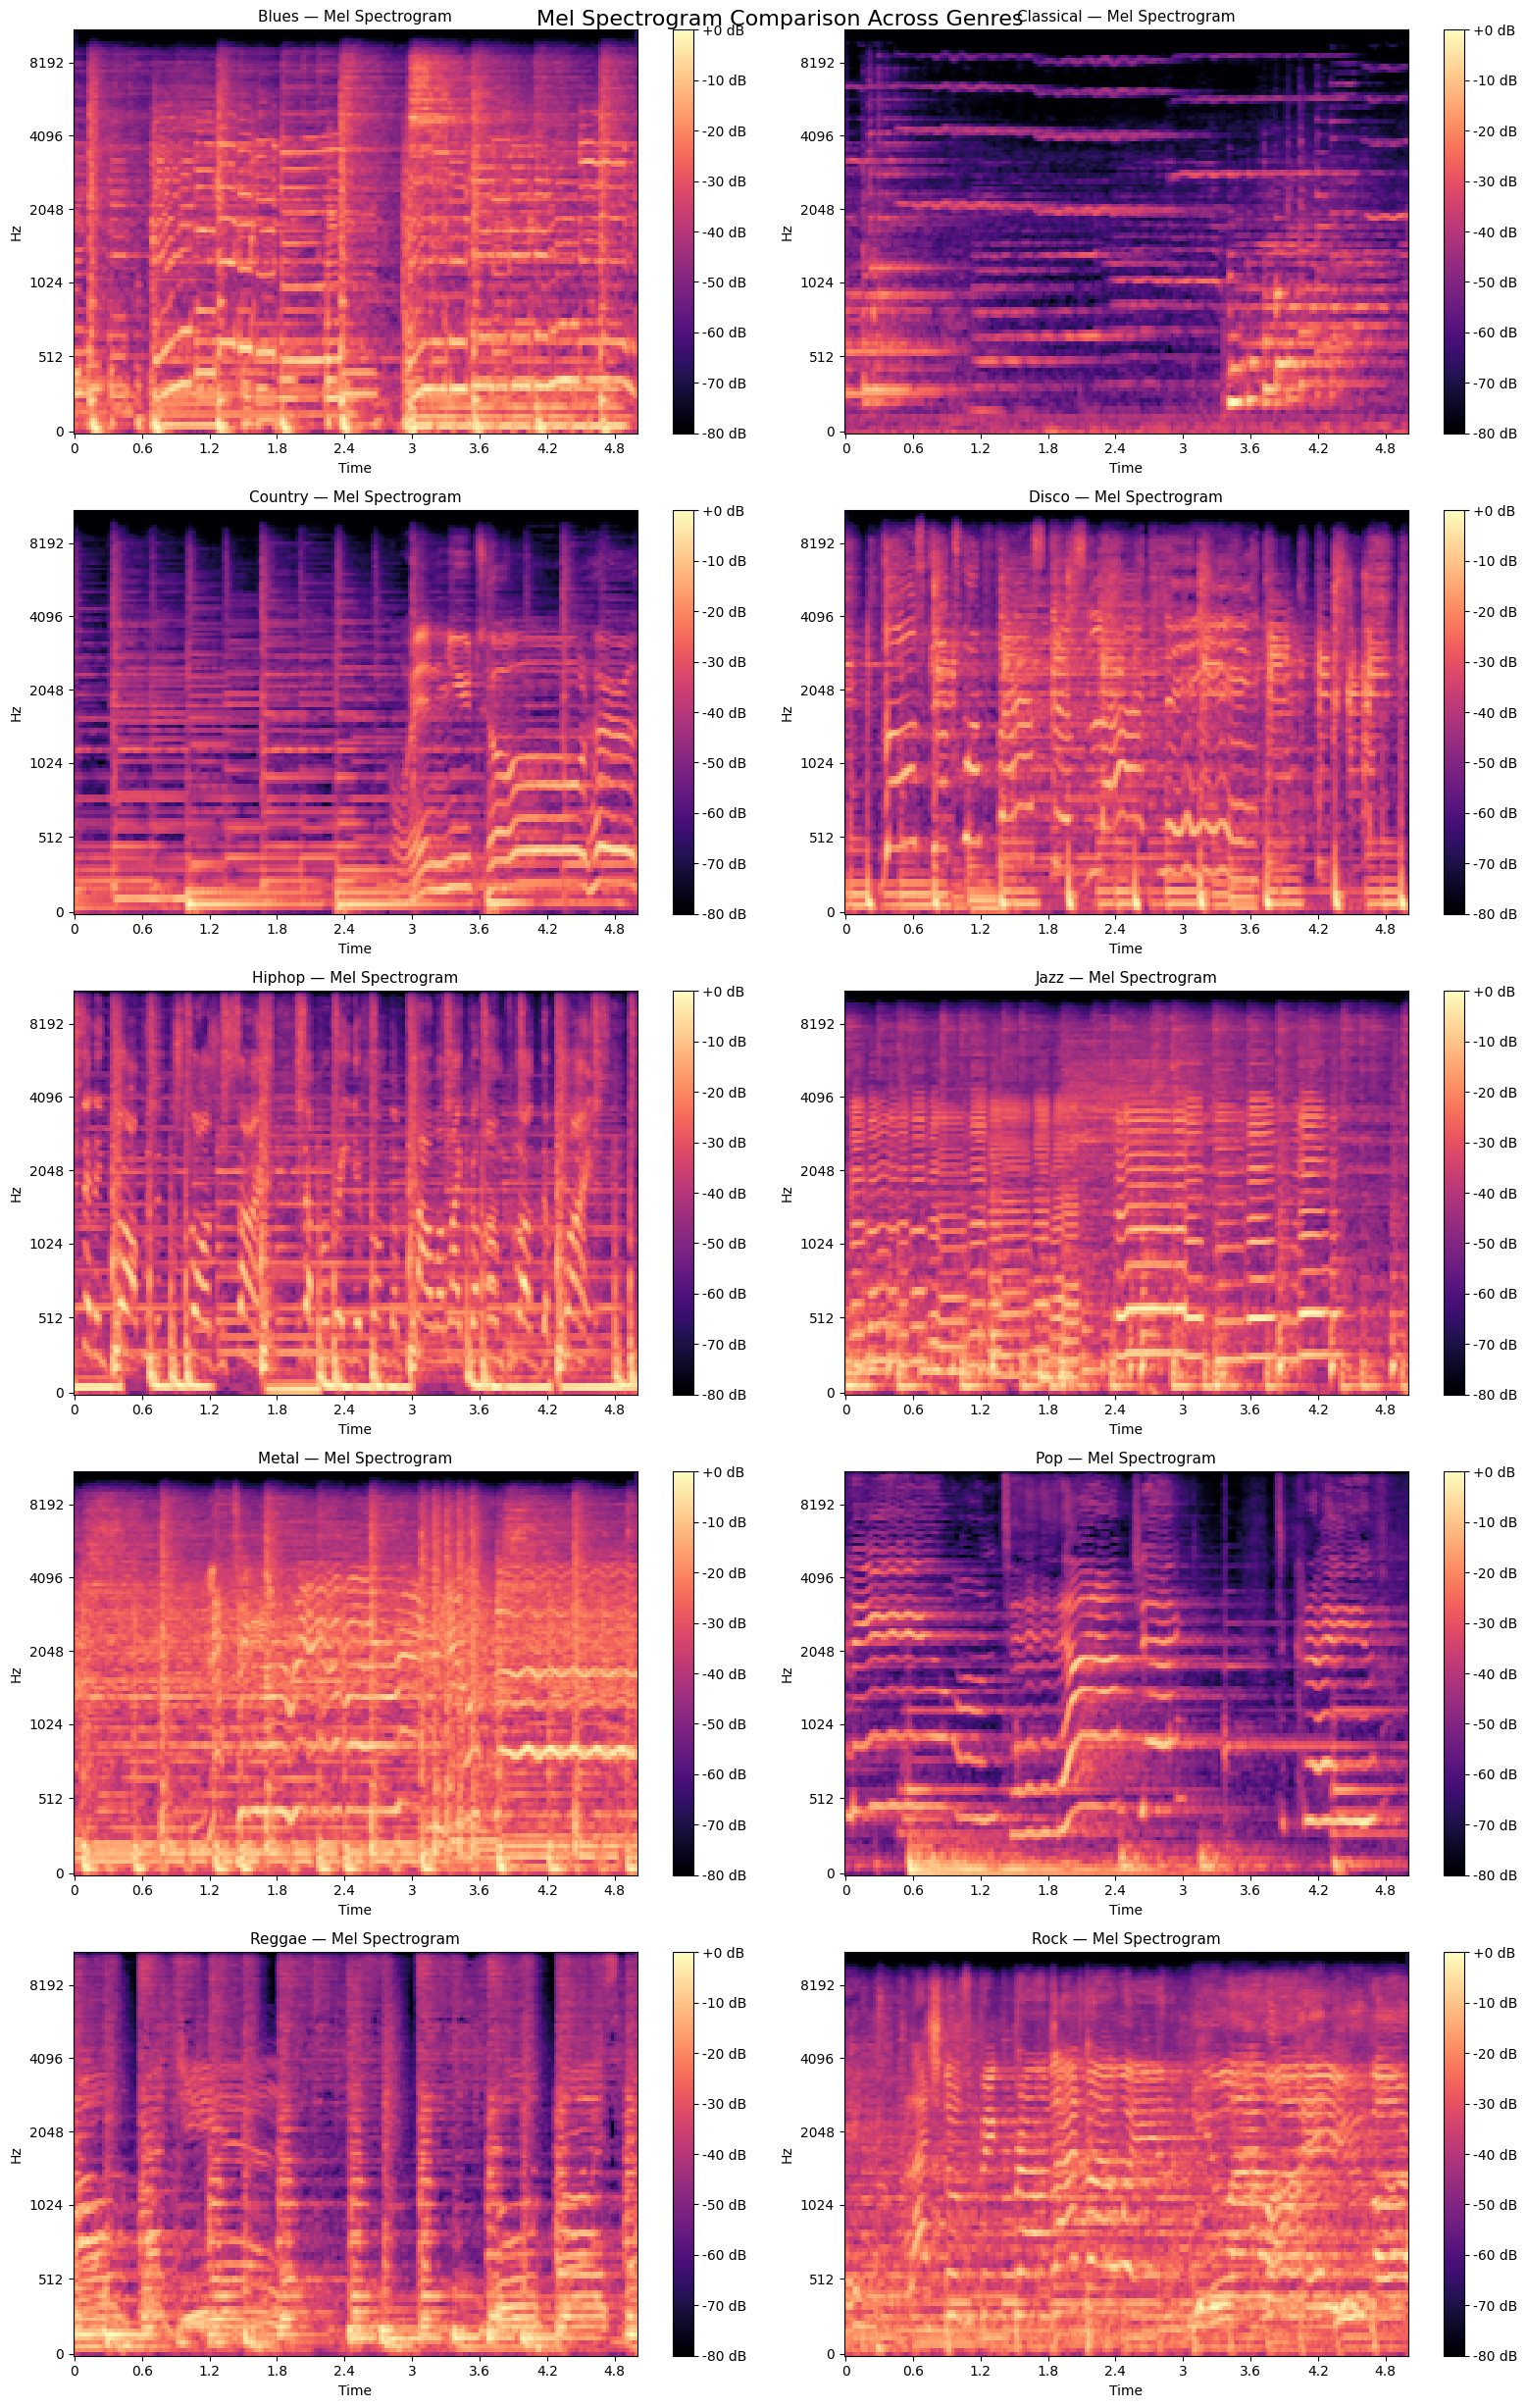

In [25]:
# Mel Spectogram Comparison

fig, axes = plt.subplots(5, 2, figsize=(16, 25))
axes = axes.flatten()

for i, genre in enumerate(GENRES):
    # Load and mix stems
    mixed = np.zeros(int(SR * DURATION))
    for key in STEM_KEYS:
        fp = tr[genre][key][0]
        y, _ = librosa.load(fp, sr=SR, duration=DURATION)
        y = librosa.util.fix_length(y, size=int(SR * DURATION))
        mixed += y

    if np.max(np.abs(mixed)) > 0:
        mixed = mixed / np.max(np.abs(mixed))

    # Compute mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=mixed, sr=SR,
        n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    img = librosa.display.specshow(
        mel_db, sr=SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel', ax=axes[i]
    )
    axes[i].set_title(f'{genre.capitalize()} — Mel Spectrogram', fontsize=11)
    fig.colorbar(img, ax=axes[i], format='%+2.0f dB')

plt.suptitle('Mel Spectrogram Comparison Across Genres', fontsize=16)
plt.tight_layout()
plt.savefig('mel_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()

- *We can apply fourier transformation on a short window of waveform to find the frequencies in it*
- *We apply Short Time Fourier Transform (STFT) by taking a sliding window on waveform and repeatedly applying fourier transform on it to get mel spectogram*
- *Stack all the windows together to get an image that depicts frequency of sound at different time intervals, colored by loudness* 

Total ESC-50 clips: 2000
Total categories:   50


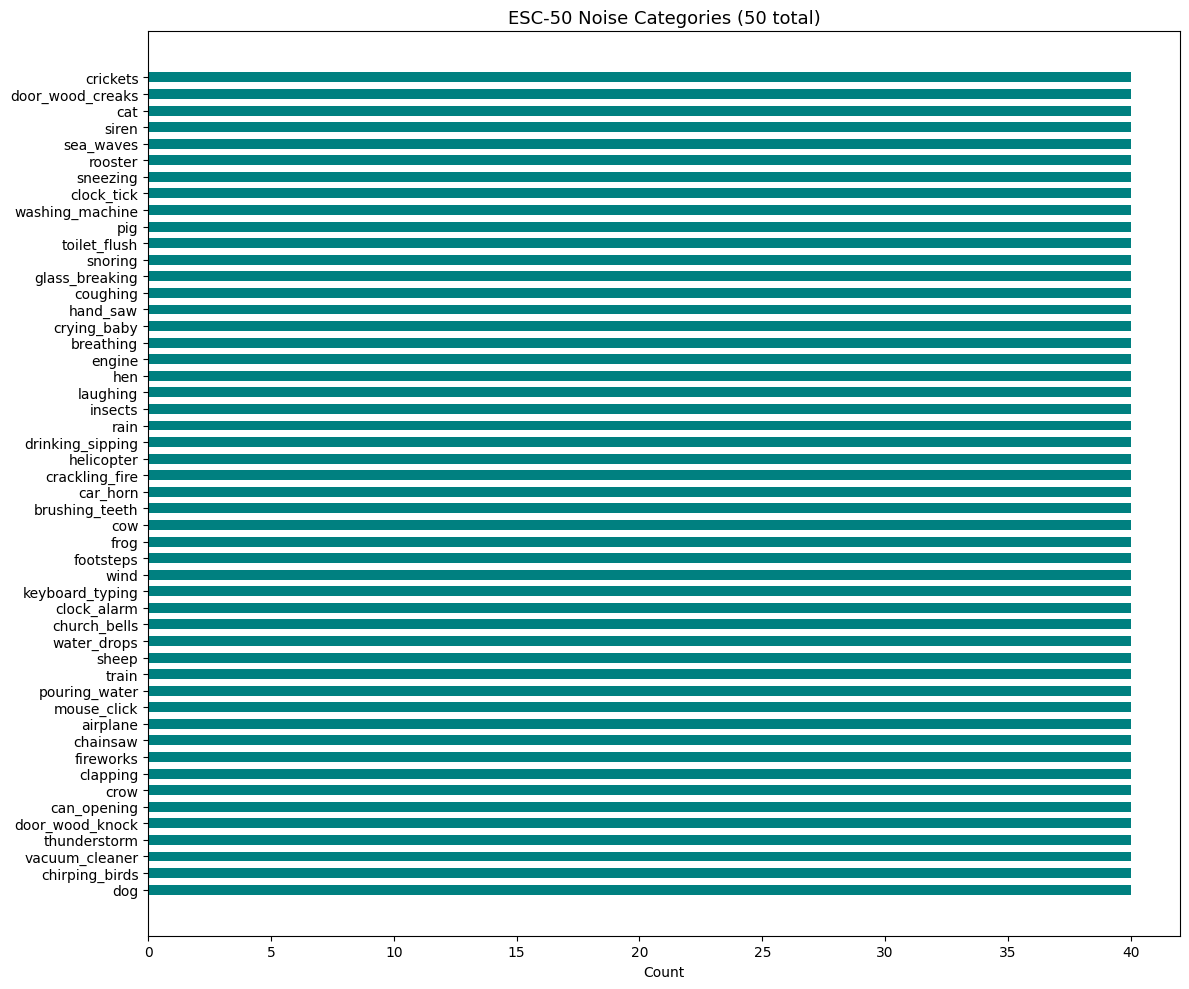

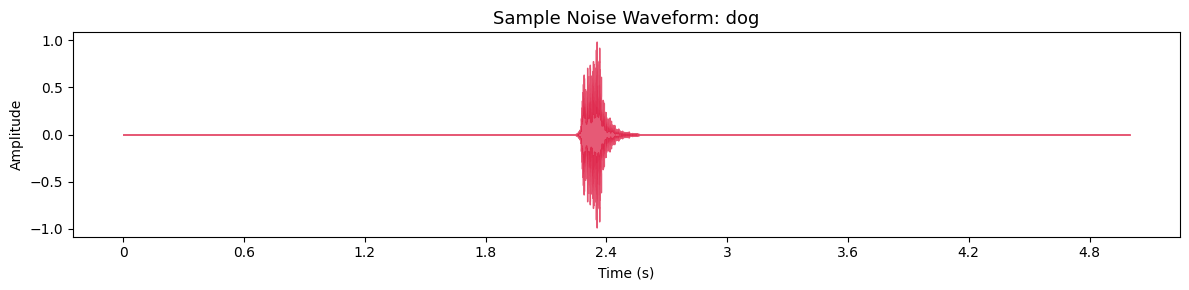

In [19]:
# ESC-50 Noise Analysis
ESC50_META  = os.path.join(DATA_ROOT, 'ESC-50-master', 'meta', 'esc50.csv')
ESC50_AUDIO = os.path.join(DATA_ROOT, 'ESC-50-master', 'audio')

esc_df = pd.read_csv(ESC50_META)
print(f"Total ESC-50 clips: {len(esc_df)}")
print(f"Total categories:   {esc_df['category'].nunique()}")

# Category distribution
plt.figure(figsize=(12, 10))
cat_counts = esc_df['category'].value_counts()
plt.barh(cat_counts.index, cat_counts.values, color='teal', height=0.6)
plt.title('ESC-50 Noise Categories (50 total)', fontsize=13)
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('esc50_categories.png', dpi=150, bbox_inches='tight')
plt.show()

# Sample noise waveform
sample_noise = os.path.join(ESC50_AUDIO, esc_df.iloc[0]['filename'])
y_noise, _   = librosa.load(sample_noise, sr=SR, duration=5.0)

plt.figure(figsize=(12, 3))
librosa.display.waveshow(y_noise, sr=SR, color='crimson', alpha=0.7)
plt.title(f"Sample Noise Waveform: {esc_df.iloc[0]['category']}", fontsize=13)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.savefig('noise_sample.png', dpi=150, bbox_inches='tight')
plt.show()

- *We combine noise audios with training audios during data augmentation*
- *All of the 50 categories have 40 audios each which mean they are equally distributed*

*Silence Analysis (From Milestone 1 notebook)*
- *Files with Silence ≥ 5 seconds*

| Genre | Bass | Drums | Other | Vocals |
|:---|:---|:---|:---|:---|
| Blues | 17 | 25 | 6 | 45 |
| Classical | 66 | 57 | 4 | 70 |
| Country | 11 | 14 | 1 | 17 |
| Disco | 7 | 2 | 3 | 18 |
| Hiphop | 20 | 3 | 17 | 4 |
| Jazz | 26 | 20 | 1 | 73 |
| Metal | 6 | 2 | 1 | 42 |
| Pop | 10 | 4 | 2 | 5 |
| Reggae | 6 | 4 | 7 | 14 |
| Rock | 12 | 8 | 1 | 27 |

# *Rule Based Submission*

In [32]:
def rule_based_predict(filepath):
    y, sr = librosa.load(filepath, sr=SR, duration=10.0)

    # 3 features
    rms      = np.mean(librosa.feature.rms(y=y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr      = np.mean(librosa.feature.zero_crossing_rate(y))

    # Rules based on energy + brightness + rhythm
    if rms < 0.02:                    return "classical"
    if rms > 0.15:                    return "metal"
    if centroid < 1500:               return "hiphop"
    if zcr > 0.10:                    return "disco"
    if rms < 0.05:                    return "jazz"
    if centroid > 3000:               return "rock"
    if zcr < 0.04:                    return "blues"
    if centroid < 2500:               return "country"
    if rms < 0.08:                    return "reggae"
    return                             "pop"

# Predict
test_df     = pd.read_csv(TEST_CSV)
predictions = []

for i, (_, row) in enumerate(test_df.iterrows()):
    filepath = MASHUPS_PATH / row['filename'].split('/')[-1]
    predictions.append(rule_based_predict(str(filepath)))

# Save
submission = pd.DataFrame({'id': test_df['id'], 'genre': predictions})
submission.to_csv('/kaggle/working/submission_rulebased.csv', index=False)
print("Prediction done")

Prediction done


In [35]:
FileLink('submission_rulebased.csv')

/kaggle/working/submission_rulebased.csv

# **Milestone 2 : Classical ML Baseline**

# *Clean, Preprocess, and Convert Audio to Numerical Features*

In [46]:
def clean_audio(y, sr, top_db=20):
    # Step 1: Trim silence from start and end
    y_trimmed, _ = librosa.effects.trim(y, top_db=top_db)

    # Step 2: Normalize amplitude to [-1, 1]
    if np.max(np.abs(y_trimmed)) > 0:
        y_trimmed = y_trimmed / np.max(np.abs(y_trimmed))

    # Step 3: Fix length (pad if short, trim if long)
    target_len = int(sr * DURATION)
    if len(y_trimmed) < target_len:
        y_trimmed = np.pad(y_trimmed, (0, target_len - len(y_trimmed)))
    else:
        y_trimmed = y_trimmed[:target_len]

    return y_trimmed


def extract_features(y, sr):
    # MFCCs
    mfcc      = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std  = np.std(mfcc, axis=1)

    # Mel Spectrogram 
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_mean = np.mean(mel_db, axis=1)
    mel_std = np.std(mel_db, axis=1)

    # Spectral Features
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))

    # Rhythm Features 
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

    # Energy Features
    rms = np.mean(librosa.feature.rms(y=y))

    # Chroma (harmonic content)
    chroma     = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma, axis=1)  

    # Concatenate everything into one vector
    features = np.concatenate([
        mfcc_mean, mfcc_std,          
        mel_mean, mel_std,           
        chroma_mean,                 
        [centroid, bandwidth,
         rolloff, contrast,
         zcr, tempo, rms]             
    ])

    return features  


def extract_song_features(song_path):
    all_features = []

    for stem in STEMS:
        stem_file = song_path / f"{stem}.wav"
        try:
            y, sr = librosa.load(stem_file, sr=SR, duration=DURATION)
            y     = clean_audio(y, sr)
            feat  = extract_features(y, sr)
        except:
            feat  = np.zeros(355)  

        all_features.append(feat)

    return np.concatenate(all_features)  


# Build Training Dataset 
print("Extracting features from training stems...")
X_train = []
y_train = []

for genre in GENRES:
    genre_path = STEMS_PATH / genre
    songs      = sorted(os.listdir(genre_path))
    print(f"  {genre}: {len(songs)} songs")

    for song in songs:
        song_path = genre_path / song
        features  = extract_song_features(Path(song_path))
        X_train.append(features)
        y_train.append(genre)

X_train = np.array(X_train)
y_train = np.array(y_train)

# Label encode
le        = LabelEncoder()
y_encoded = le.fit_transform(y_train)

print(f"\nFeature matrix shape: {X_train.shape}")
print(f"Labels shape:         {y_encoded.shape}")

# Train/val split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)
print(f"\nTrain: {X_tr.shape} | Val: {X_val.shape}")

# Scale features 
scaler = StandardScaler()
X_tr_scaled  = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

Extracting features from training stems...
  blues: 100 songs
  classical: 100 songs
  country: 100 songs
  disco: 100 songs
  hiphop: 100 songs
  jazz: 100 songs
  metal: 100 songs
  pop: 100 songs
  reggae: 100 songs
  rock: 100 songs

Feature matrix shape: (1000, 1420)
Labels shape:         (1000,)

Train: (800, 1420) | Val: (200, 1420)


# *ML Baseline Model (Logistic Regression) with Macro F1 evaluation and Wandb Logging*

In [51]:
# Train Logistic Regression
run = wandb.init(
    project="messy-mashup",
    name="Logistic_Regression",
    tags=["classical-ml", "phase-2"],
    config={"model": "Logistic Regression", "features": "MFCC+Mel+Chroma+Spectral"}
)

print("Training Logistic Regression...")
model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
model.fit(X_tr_scaled, y_tr)

# Evaluate
train_preds = model.predict(X_tr_scaled)
val_preds   = model.predict(X_val_scaled)
train_f1    = f1_score(y_tr,  train_preds, average='macro')
val_f1      = f1_score(y_val, val_preds,   average='macro')

# Per genre F1
per_genre_f1 = f1_score(y_val, val_preds, average=None)
per_genre    = {le.classes_[i]: round(per_genre_f1[i], 4) for i in range(len(le.classes_))}

# Log to W&B
wandb.log({
    "train_macro_f1": train_f1,
    "val_macro_f1":   val_f1,
    **{f"f1_{g}": v for g, v in per_genre.items()}
})

# Log as table
table = wandb.Table(
    columns=["Model", "Train Macro F1", "Val Macro F1"] + [str(g) for g in per_genre.keys()],
    data=[["Logistic Regression", round(train_f1, 4), round(val_f1, 4)] + [float(v) for v in per_genre.values()]]
)
wandb.log({"results": table})

wandb.finish()

print(f"Train F1: {train_f1:.4f}")
print(f"Val F1:   {val_f1:.4f}")

Training Logistic Regression...


f1_blues,▁
f1_classical,▁
f1_country,▁
f1_disco,▁
f1_hiphop,▁
f1_jazz,▁
f1_metal,▁
f1_pop,▁
f1_reggae,▁
f1_rock,▁
+2,...


Train F1: 0.6889
Val F1:   0.3561


In [54]:
predictions = []

for i, (_, row) in enumerate(test_df.iterrows()):
    mashup_path = MASHUPS_PATH / row['filename'].split('/')[-1]
    
    try:
        y, sr = librosa.load(mashup_path, sr=SR, duration=DURATION)
        y     = clean_audio(y, sr)
        feat  = extract_features(y, sr)  # 355 features
        
        # Repeat 4 times to match training shape of 1420
        feat  = np.tile(feat, 4)  # (1420,)
    except:
        feat  = np.zeros(1420)
    
    feat_scaled = scaler.transform([feat])
    pred        = model.predict(feat_scaled)[0]
    predictions.append(le.inverse_transform([pred])[0])

submission = pd.DataFrame({'id': test_df['id'], 'genre': predictions})
submission.to_csv('/kaggle/working/submission_lr.csv', index=False)
print("prediction done")

prediction done


In [55]:
FileLink('submission_lr.csv')

/kaggle/working/submission_lr.csv

# **Milestone 3 : First Neural Network & CNNs**

# *Augmenting Audio Data*

In [3]:
# Data Augmentation

# Load noise files
print("Loading ESC-50 noise files...")
noise_files = list(ESC50_PATH.glob("*.wav"))

def load_audio(path, duration=DURATION, sr=SR):
    y, _ = librosa.load(path, sr=sr, duration=duration)
    target_len = int(sr * duration)  # ← add int()
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y

def mix_stems(genre_path):
    songs  = list(genre_path.iterdir())
    mixed  = np.zeros(int(SR * DURATION))
    for stem in STEMS:
        song      = random.choice(songs)
        stem_file = song / f"{stem}.wav"
        if stem_file.exists():
            audio  = load_audio(stem_file)
            mixed += audio
    if np.max(np.abs(mixed)) > 0:
        mixed = mixed / np.max(np.abs(mixed))
    return mixed

def add_noise(audio, noise_files, min_snr=0, max_snr=15):
    n_noises = random.randint(1, 2)
    for _ in range(n_noises):
        noise_file   = random.choice(noise_files)
        noise        = load_audio(noise_file, duration=DURATION)
        snr          = random.uniform(min_snr, max_snr)
        signal_power = np.mean(audio ** 2)
        noise_power  = np.mean(noise ** 2)
        if noise_power > 0:
            noise_scale = np.sqrt(signal_power / (noise_power * (10 ** (snr / 10))))
            noise       = noise * noise_scale
        audio = audio + noise
    return audio

# Create augmented dataset
print("\nCreating augmented dataset...")
X_raw, y_labels = [], []

for genre in GENRES:
    genre_path = STEMS_PATH / genre
    print(f"  Augmenting {genre}...")
    for _ in range(500):
        mixed = mix_stems(genre_path)
        noisy = add_noise(mixed, noise_files)
        X_raw.append(noisy)
        y_labels.append(genre)

# Save to disk
with open("/kaggle/working/X_raw.pkl", "wb") as f:
    pickle.dump(X_raw, f)
with open("/kaggle/working/y_labels.pkl", "wb") as f:
    pickle.dump(y_labels, f)

print(f"\nDataset created and saved")

Loading ESC-50 noise files...

Creating augmented dataset...
  Augmenting blues...
  Augmenting classical...
  Augmenting country...
  Augmenting disco...
  Augmenting hiphop...
  Augmenting jazz...
  Augmenting metal...
  Augmenting pop...
  Augmenting reggae...
  Augmenting rock...

Dataset created and saved


In [ ]:
print("Loading augmented data from disk...")
with open("/kaggle/working/X_raw.pkl", "rb") as f:
    X_raw = pickle.load(f)
with open("/kaggle/working/y_labels.pkl", "rb") as f:
    y_labels = pickle.load(f)

print(f"Loaded {len(X_raw)} samples")

# *Convert audio to 2D/1D Mel-Spectrograms*

In [4]:
# Creating Mel Spectogram Image dataset

# Mel Spectrogram transform
mel_transform = T.MelSpectrogram(
    sample_rate=SR,
    n_fft=2048,
    hop_length=512,
    n_mels=N_MELS,
    power=2.0
)
db_transform = T.AmplitudeToDB(top_db=80)

def audio_to_mel(audio_np):
    # numpy → tensor
    waveform = torch.FloatTensor(audio_np).unsqueeze(0)  # (1, samples)

    # mel spectrogram
    mel = mel_transform(waveform)   # (1, 128, time)
    mel = db_transform(mel)         # convert to dB

    # Normalize to [-1, 1]
    mel = (mel - mel.mean()) / (mel.std() + 1e-8)

    # Fixed size — resize time axis to 216
    mel = F.interpolate(
        mel.unsqueeze(0),
        size=(N_MELS, 216),
        mode='bilinear',
        align_corners=False
    ).squeeze(0)

    return mel  # (1, 128, 216)


class MelDataset(Dataset):
    def __init__(self, audio_list, labels):
        self.audio_list = audio_list
        self.labels     = labels

    def __len__(self):
        return len(self.audio_list)

    def __getitem__(self, idx):
        mel   = audio_to_mel(self.audio_list[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label


# Label encode
le        = LabelEncoder()
le.fit(GENRES)
y_encoded = le.transform(y_labels)

# Train/val split
indices   = list(range(len(X_raw)))
random.shuffle(indices)
split     = int(0.9 * len(X_raw))
train_idx = indices[:split]
val_idx   = indices[split:]

train_dataset = MelDataset(
    [X_raw[i] for i in train_idx],
    [y_encoded[i] for i in train_idx]
)
val_dataset = MelDataset(
    [X_raw[i] for i in val_idx],
    [y_encoded[i] for i in val_idx]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"Mel shape: {audio_to_mel(X_raw[0]).shape}")

Train: 4500 | Val: 500
Mel shape: torch.Size([1, 128, 216])


# *Build a CNN*

In [5]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, pool_size=(2,2), dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3, padding=1),  
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels,
                      kernel_size=3, padding=1),  
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(pool_size),
            nn.Dropout2d(dropout)
        )

    def forward(self, x):
        return self.block(x)


class GenreCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.cnn = nn.Sequential(
            CNNBlock(1,   32,  pool_size=(2,2), dropout=0.2),  
            CNNBlock(32,  64,  pool_size=(2,2), dropout=0.2), 
            CNNBlock(64,  128, pool_size=(2,2), dropout=0.3),  
            CNNBlock(128, 256, pool_size=(2,2), dropout=0.3),  
        )


        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)        # extract features
        x = self.gap(x)        # global average pool
        x = self.classifier(x) # classify
        return x


# Init model
model = GenreCNN(num_classes=10).to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Test forward pass
dummy = torch.randn(2, 1, 128, 216).to(device)
out   = model(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}")  # should be (2, 10)

Total parameters: 1,207,786
Input shape:  torch.Size([2, 1, 128, 216])
Output shape: torch.Size([2, 10])


# *Implement training loop, loss, optimizer, and wandb logging*

In [6]:
# W&B init
wandb.init(
    project="messy-mashup",
    name="CNN_scratch",
    tags=["phase-3", "cnn"],
    config={
        "model": "CNN from scratch",
        "epochs": 20,
        "batch_size": 32,
        "lr": 1e-3,
        "n_mels": N_MELS,
        "duration": DURATION,
        "sr": SR,
        "optimizer": "AdamW",
        "loss": "CrossEntropyLoss"
    }
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20, eta_min=1e-5
)
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct = 0, 0
    for mel, labels in loader:
        mel, labels = mel.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(mel)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        total_correct += (logits.argmax(1) == labels).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for mel, labels in loader:
            mel, labels = mel.to(device), labels.to(device)
            logits = model(mel)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), macro_f1

EPOCHS = 20
PATIENCE = 3
best_f1 = 0
no_improve = 0

print("Starting CNN training...")
print("-" * 60)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_f1 = eval_epoch(model, val_loader,   criterion)
    scheduler.step()

    # Log to W&B
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_f1": val_f1,
        "val_loss": val_loss,
        "learning_rate": optimizer.param_groups[0]['lr']
    })

    # Save best model
    torch.save(
        model.state_dict(),
        f"/kaggle/working/cnn_epoch{epoch+1:02d}_f1{val_f1:.4f}.pth"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        no_improve = 0
        torch.save(model.state_dict(), "/kaggle/working/cnn_best.pth")
        print(f"Epoch {epoch+1:02d} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Val F1: {val_f1:.4f}  model saved")
    else:
        no_improve += 1
        print(f"Epoch {epoch+1:02d} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Val F1: {val_f1:.4f} ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

wandb.finish()
print(f"\nBest Val F1: {best_f1:.4f}")

Starting CNN training...
------------------------------------------------------------
Epoch 01 | Loss: 2.1077 | Acc: 0.2098 | Val F1: 0.2556  model saved
Epoch 02 | Loss: 1.9111 | Acc: 0.2853 | Val F1: 0.3247  model saved
Epoch 03 | Loss: 1.8033 | Acc: 0.3158 | Val F1: 0.3284  model saved
Epoch 04 | Loss: 1.7504 | Acc: 0.3369 | Val F1: 0.3781  model saved
Epoch 05 | Loss: 1.7031 | Acc: 0.3489 | Val F1: 0.3857  model saved
Epoch 06 | Loss: 1.6684 | Acc: 0.3682 | Val F1: 0.3914  model saved
Epoch 07 | Loss: 1.6298 | Acc: 0.3769 | Val F1: 0.4074  model saved
Epoch 08 | Loss: 1.5726 | Acc: 0.4096 | Val F1: 0.4577  model saved
Epoch 09 | Loss: 1.5586 | Acc: 0.4096 | Val F1: 0.4994  model saved
Epoch 10 | Loss: 1.5335 | Acc: 0.4236 | Val F1: 0.4728 (1/3)
Epoch 11 | Loss: 1.4929 | Acc: 0.4360 | Val F1: 0.5020  model saved
Epoch 12 | Loss: 1.4591 | Acc: 0.4482 | Val F1: 0.4947 (1/3)
Epoch 13 | Loss: 1.4196 | Acc: 0.4622 | Val F1: 0.5195  model saved
Epoch 14 | Loss: 1.3824 | Acc: 0.4787 | Val 

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
learning_rate,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
train_acc,▁▃▃▄▄▄▅▅▅▆▆▆▇▇▇█████
train_loss,█▆▅▅▅▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁
val_f1,▁▃▃▄▄▄▄▅▆▆▆▆▇▇██████
val_loss,█▇▇▆▅▅▄▄▃▃▃▃▂▂▂▁▁▁▁▁
epoch,20
learning_rate,1e-05
train_acc,0.52711
train_loss,1.28073
val_f1,0.57094



Best Val F1: 0.5750


# *Evaluate CNN Model*

In [11]:
# Load best CNN model
model.load_state_dict(torch.load("/kaggle/working/cnn_best.pth"))
model.eval()

test_df     = pd.read_csv(TEST_CSV)
predictions = []

for i, (_, row) in enumerate(test_df.iterrows()):
    mashup_path = MASHUPS_PATH / row['filename'].split('/')[-1]

    # Load audio
    y, sr = librosa.load(mashup_path, sr=SR, duration=DURATION)
    y     = np.pad(y, (0, max(0, SR * DURATION - len(y))))

    # Convert to mel
    mel   = audio_to_mel(y).unsqueeze(0).to(device)  # (1, 1, 128, 216)

    with torch.no_grad():
        logits   = model(mel)
        probs    = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()

    predictions.append(le.inverse_transform([pred_idx])[0])

submission = pd.DataFrame({'id': test_df['id'], 'genre': predictions})
submission.to_csv('/kaggle/working/submission_cnn.csv', index=False)
print("prediction done")

prediction done


In [12]:
FileLink('submission_cnn.csv')

/kaggle/working/submission_cnn.csv